# Linear Regression Model — Airbnb Rome Price Prediction (v2)

Rebuilt after the latest commit. This version reflects what's **actually** in the repo now,
not what the earlier plan assumed. Summary of what changed and what's still open below.


## Status check after the latest commit

**Confirmed / resolved:**
- Target variable is settled: `01_calendar_cleaning.ipynb` now states explicitly that
  `calendar.csv` never had `price`/`adjusted_price` columns at all, so `listings.price` is the
  target. No more ambiguity here.
- `02_listings_cleaning.ipynb` now exports `data/listings_features.csv` at the end. ✅
- New host features were added: `host_experience_days`, `professional_host` — matches the
  Word plan's Step 5. `property_type` categories were also consolidated (e.g. "Entire rental
  unit" → "Apartment"), reducing cardinality before encoding.
- The IQR-based outlier removal on `latitude`/`longitude` before clustering is now **commented
  out** (`#coords = coords.loc[valid_mask].copy()`), so K-Means/DBSCAN now run on the full
  coordinate set — worth double-checking with whoever made that change that it's intentional,
  since it changes the cluster shapes from what was analyzed in the elbow/silhouette plots.

**Still open / blocking issues — flag these to the group:**

1. **`id` is still not in `candidate_features`** in `02_listings_cleaning.ipynb`. This has been
   flagged twice now. Without it, `listings_features.csv` cannot be merged with
   `review_features.csv` (which is keyed on `listing_id`).
2. **`05_final_dataset.ipynb` is completely empty (0 bytes).** Both this notebook and
   `06_random_forest.ipynb` need a merged final dataset, and neither can actually get one yet.
3. **`06_random_forest.ipynb` assumes a schema that doesn't match any notebook's real output** —
   it literally has the comment `# need to define the final dataset**` on the load line. It
   expects columns like `last_review`, `latest_review_date`, raw `neighbourhood`, raw
   `room_type` (not one-hot encoded) in `final_dataset.csv`. But: `last_review` is dropped in
   `02_listings_cleaning.ipynb`, `latest_review_date` is computed in `03_reviews_analysis.ipynb`
   but never actually merged into the saved `review_features.csv` (only `review_count` and
   `avg_review_length` get saved), and `neighbourhood_cleansed` is already one-hot encoded
   upstream. Someone needs to agree on one actual schema for `final_dataset.csv` before both
   models can run on the same data — worth a quick sync with whoever owns Random Forest.
4. Repo hygiene: `WRONG02_listings_cleaning.ipynb` looks like a leftover from a merge conflict —
   probably worth deleting before the final submission so no one accidentally works from it.

**Given all this, this notebook is built defensively**: it looks for `final_dataset.csv` first,
and falls back to `listings_features.csv` alone (which does exist and has a well-defined
schema) if the merge hasn't happened yet — so you're not blocked waiting on point 2/3 above.

**v2 fixes (from running this on real data):**
- `mean_squared_error(..., squared=False)` was removed in newer scikit-learn versions (yours
  raised `TypeError: unexpected keyword argument 'squared'`) -- now computed as
  `np.sqrt(mean_squared_error(...))`, which works on every version.
- `host_response_rate`, `host_acceptance_rate`, `host_experience_days` (and possibly others)
  came back 100% missing in your actual data, which made `SimpleImputer(strategy="median")`
  choke silently. Added a step that detects and drops any fully-empty column before fitting,
  and prints exactly which ones -- check that list against your data, since a column you
  expected to have values being 100% empty usually means something upstream (a wrong source
  column, a merge that didn't line up) needs fixing.


## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = Path.cwd().parent
RANDOM_STATE = 42

print("Project root:", PROJECT_ROOT)


Project root: /Users/antoniacordova/Data for business/airbnb-rome-analysis


## 2. Load data — final_dataset.csv if it exists, otherwise listings_features.csv alone

In [2]:
final_path = PROJECT_ROOT / "data" / "final_dataset.csv"
listings_path = PROJECT_ROOT / "data" / "listings_features.csv"
reviews_path = PROJECT_ROOT / "data" / "review_features.csv"

if final_path.exists():
    selected = pd.read_csv(final_path)
    print(f"Loaded merged dataset from {final_path.name} -- shape: {selected.shape}")
elif listings_path.exists():
    selected = pd.read_csv(listings_path)
    print(
        f"{final_path.name} not found yet (05_final_dataset.ipynb is still empty) -- "
        f"falling back to {listings_path.name} alone. Shape: {selected.shape}"
    )
    if reviews_path.exists():
        print(
            f"Note: {reviews_path.name} exists but can't be merged in -- "
            f"{listings_path.name} has no 'id'/'listing_id' column yet to join on."
        )
else:
    raise FileNotFoundError(
        f"Could not find {final_path} or {listings_path}.\n"
        "Run 02_listings_cleaning.ipynb first (it exports listings_features.csv at the end)."
    )

selected.head()


Loaded merged dataset from final_dataset.csv -- shape: (33564, 75)


,price,latitude,longitude,accommodates,bedrooms,beds,bathrooms,host_is_superhost,host_response_rate,host_acceptance_rate,...,distance_to_colosseum,location_cluster,review_count,avg_review_length,avg_sentiment_score,sentiment_label,latest_review_year,latest_review_month,latest_review_day,days_since_latest_review
0,57.0,41.871360,12.482150,1,1.0,1.0,1.5,0,0.0,0.0,...,2.252726,3.0,5.0,51.800000,0.956560,positive,2015.0,5.0,8.0,3783.0
1,110.0,41.895447,12.491181,2,1.0,1.0,1.0,1,100.0,95.0,...,0.588865,4.0,284.0,76.450704,0.849984,positive,2025.0,7.0,5.0,72.0
2,124.0,41.925820,12.469280,6,2.0,3.0,1.0,1,100.0,100.0,...,4.389669,1.0,85.0,84.658824,0.719140,positive,2025.0,8.0,1.0,45.0
3,162.0,41.908230,12.452930,5,2.0,3.0,1.0,0,100.0,99.0,...,3.824847,1.0,178.0,44.410112,0.463074,positive,2025.0,8.0,5.0,41.0
4,150.0,41.908283,12.452617,5,2.0,3.0,1.0,0,100.0,99.0,...,3.850102,1.0,46.0,33.673913,0.380039,positive,2024.0,7.0,19.0,423.0


In [3]:
selected.info()


<class 'pandas.DataFrame'>
RangeIndex: 33564 entries, 0 to 33563
Data columns (total 75 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   price                                              33564 non-null  float64
 1   latitude                                           33564 non-null  float64
 2   longitude                                          33564 non-null  float64
 3   accommodates                                       33564 non-null  int64  
 4   bedrooms                                           33564 non-null  float64
 5   beds                                               33564 non-null  float64
 6   bathrooms                                          33564 non-null  float64
 7   host_is_superhost                                  33564 non-null  int64  
 8   host_response_rate                                 33564 non-null  float64
 9   host_acceptance_r

## 3. Define target and features

- **Target (`y`)**: `price` — static nightly price from `listings.csv`, confirmed as the
  correct target in `01_calendar_cleaning.ipynb`.
- **`id` / `listing_id`**: excluded from `X` if present — not predictive, only useful for
  merges. (Currently absent from `listings_features.csv` — see status note above.)


In [4]:
target = "price"
id_cols = [c for c in ["id", "listing_id"] if c in selected.columns]

selected = selected.dropna(subset=[target])

X = selected.drop(columns=[target] + id_cols)
y = selected[target]

print("Features:", X.shape[1], "| Rows:", X.shape[0])
print("Id columns excluded from modeling:", id_cols if id_cols else "(none found)")


Features: 74 | Rows: 33564
Id columns excluded from modeling: (none found)


## 4. Identify numeric vs. categorical columns

Split by dtype automatically, so this notebook keeps working regardless of which schema
(`final_dataset.csv` or `listings_features.csv`) ended up loaded above.

Caveats worth knowing about the current feature set:
- `location_cluster` / `dbscan_cluster` are unordered cluster labels stored as integers —
  treated here as plain numeric for simplicity. A cleaner version would one-hot encode them.
- If `final_dataset.csv` is loaded and still has `neighbourhood`/`room_type` as raw text (per
  `06_random_forest.ipynb`'s assumption), they'll be picked up automatically by the categorical
  branch below and one-hot encoded here too.


In [5]:
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "string", "category"]).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}):", categorical_cols)
print(f"Numeric columns ({len(numeric_cols)}):", numeric_cols)


Categorical columns (1): ['sentiment_label']
Numeric columns (73): ['latitude', 'longitude', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'number_of_reviews', 'reviews_per_month', 'minimum_nights', 'maximum_nights', 'beds_per_guest', 'bathrooms_per_guest', 'amenities_count', 'has_wifi', 'has_air_conditioning', 'has_kitchen', 'has_washer', 'has_dryer', 'has_parking', 'has_elevator', 'has_tv', 'has_workspace', 'host_experience_days', 'professional_host', 'property_type_Dome', 'property_type_Entire Home', 'property_type_Hotel', 'property_type_Private Room', 'property_type_Private room in boat', 'property_type_Shared Room', 'property_type_Shared room in loft', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'instant_bookable_t', 'review_quality_index', 'listing_age_days', 'review_recency_days'

### 4b. Drop fully-empty columns

If a column is 100% missing (e.g. `host_response_rate`, `host_acceptance_rate`,
`host_experience_days` showed up empty for some of you), `SimpleImputer(strategy="median")`
can't impute it -- there's no value to compute a median from -- and raises a warning while
silently producing an all-NaN column, which breaks the model downstream. We drop any column
that is 100% missing here and print which ones, so it's visible rather than a silent warning.

If this prints columns you expected to have data, that's a signal to go back to
`02_listings_cleaning.ipynb` (or wherever `final_dataset.csv` gets built) and check why they
ended up empty -- e.g. the wrong source column was referenced during the merge.


In [6]:
all_missing = X.columns[X.isna().all()].tolist()

if all_missing:
    print("Dropping fully-empty columns (0 non-missing values):", all_missing)
    X = X.drop(columns=all_missing)
    numeric_cols = [c for c in numeric_cols if c not in all_missing]
    categorical_cols = [c for c in categorical_cols if c not in all_missing]
else:
    print("No fully-empty columns found.")


No fully-empty columns found.


## 5. Train / test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (26851, 74)
Test shape: (6713, 74)


## 6. Preprocessing + Linear Regression pipeline

- Numeric: median imputation + standard scaling.
- Categorical (`property_type`, `room_type`, `instant_bookable`, and any raw text columns that
  slipped through): most-frequent imputation + one-hot encoding with `drop="first"` to avoid the
  dummy variable trap. Note `neighbourhood_cleansed` was already one-hot encoded upstream in
  `02_listings_cleaning.ipynb` **without** `drop_first`, so some multicollinearity may remain
  there regardless of what this pipeline does.


In [8]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])

model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If

## 7. Fit the model

In [9]:
model.fit(X_train, y_train)
print("Model fitted.")


Model fitted.


## 8. Evaluate performance

In [10]:
def evaluate(model, X, y, label):
    preds = model.predict(X)
    # np.sqrt(mean_squared_error(...)) instead of squared=False: that argument was
    # removed in newer scikit-learn versions (root_mean_squared_error is the new
    # dedicated function, but computing it manually keeps this notebook version-proof).
    rmse = np.sqrt(mean_squared_error(y, preds))
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    print(f"[{label}] RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")
    return preds

train_preds = evaluate(model, X_train, y_train, "Train")
test_preds = evaluate(model, X_test, y_test, "Test")


[Train] RMSE: 411.41 | MAE: 103.89 | R2: 0.0824
[Test] RMSE: 472.68 | MAE: 112.20 | R2: 0.0849


Compare these numbers against `06_random_forest.ipynb`'s MAE once that notebook is running on
the same, agreed-upon `final_dataset.csv` -- right now the two models aren't guaranteed to be
looking at the same features, so any comparison would be apples-to-oranges.

**If R² comes out low (e.g. under ~0.2) on both train and test:** that's not a bug, it's a
genuine signal that price doesn't have a strong *linear* relationship with these features --
which is exactly the justification for also trying Random Forest (captures non-linear
relationships) and comparing. Since train and test R²/RMSE are close to each other, that rules
out overfitting as the explanation; the more likely causes are (a) a few very high-priced
listings pulling the linear fit around -- worth checking `y.describe()` and trying
`np.log1p(price)` as the target instead, or (b) genuinely non-linear effects (e.g. price jumps
a lot between neighbourhoods or room types in ways a straight line can't capture) that Random
Forest should pick up better.


## 9. Residual analysis

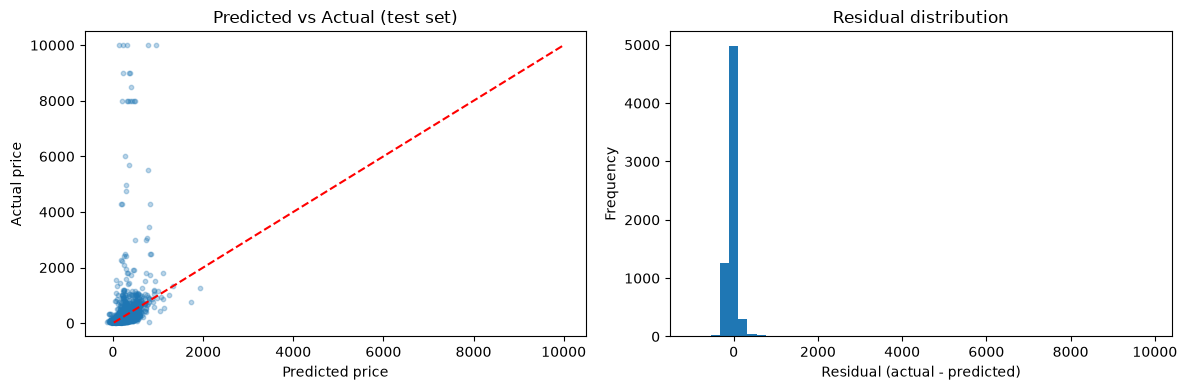

In [11]:
residuals = y_test - test_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(test_preds, y_test, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
axes[0].set_xlabel("Predicted price")
axes[0].set_ylabel("Actual price")
axes[0].set_title("Predicted vs Actual (test set)")

axes[1].hist(residuals, bins=50)
axes[1].set_xlabel("Residual (actual - predicted)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()


If residuals fan out at higher prices (heteroscedasticity) or look skewed, a `log1p(price)`
target is a common fix worth trying as a variant.


## 10. Coefficients — feature importance / interpretability

In [12]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_

coef_table = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)

coef_table.head(20)


,feature,coefficient
0,num__days_since_latest_review,-23993.322124
1,num__latest_review_year,-20959.413103
2,num__review_recency_days,20745.191855
3,num__days_since_last_review,-19850.121317
4,cat__sentiment_label_no_reviews,7165.122916
5,num__review_count,663.475064
6,num__number_of_reviews,-656.815865
7,num__bathrooms,77.902671
8,cat__sentiment_label_positive,-67.755280
9,num__property_type_Private Room,-63.839431


In [13]:
coef_table[
    coef_table["feature"].str.contains(
        "sentiment",
        case=False,
        na=False
    )
]

,feature,coefficient
4,cat__sentiment_label_no_reviews,7165.122916
8,cat__sentiment_label_positive,-67.755280
11,num__avg_sentiment_score,33.132429
38,cat__sentiment_label_neutral,-5.944577


### Sentiment Features

The sentiment-derived variables were retained in the model. The continuous variable `avg_sentiment_score` showed a positive association with price, suggesting that listings receiving more positive reviews tend to have higher prices.

The categorical sentiment variables were also included through one-hot encoding. Their coefficients should be interpreted with caution because they depend on the chosen reference category and may be affected by multicollinearity.

### Sentiment Features

The model also incorporates sentiment-derived variables extracted from guest reviews.

- avg_sentiment_score captures the average positivity or negativity of reviews.
- sentiment_label provides a categorical representation of guest sentiment.

These features allow the model to evaluate whether guest perceptions contribute to Airbnb pricing beyond traditional review ratings.

Numeric features were standardized, so coefficients are directly comparable in magnitude:
larger absolute value → stronger association with price, holding other features constant.
Useful for the Feature Selection section of the presentation and for comparing against whatever
Random Forest and Lasso end up finding.


## 11. Summary and open items for the group

- **Target**: `price` (static, from `listings.csv`) — confirmed.
- **Model**: Linear Regression baseline, single `sklearn` Pipeline (impute → scale/one-hot →
  fit), `random_state=42` throughout for reproducibility.
- **Blocking items to resolve before final comparison across models:**
  1. Add `"id"` to `candidate_features` in `02_listings_cleaning.ipynb`.
  2. Actually build `05_final_dataset.ipynb` (merge `listings_features.csv` +
     `review_features.csv` on `id`/`listing_id`) — right now it's empty.
  3. Get `06_random_forest.ipynb` and this notebook reading the *same* `final_dataset.csv`
     schema — right now Random Forest assumes columns (`last_review`, `latest_review_date`,
     raw `neighbourhood`/`room_type`) that don't exist in the current pipeline output.
  4. Decide whether to keep the coordinate outlier removal commented out in
     `02_listings_cleaning.ipynb`, since that changes what the clusters look like.
  5. Delete `WRONG02_listings_cleaning.ipynb` from the repo once everyone's confirmed which
     version is the real one.
